In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [108]:
df_pos=pd.read_csv('../../../data/processed/major_leagues/Sofascore_player_data_2526.csv')

C:\Users\vibha\AppData\Local\Temp\ipykernel_16368\14935580.py:1: DtypeWarning: Columns (0: yellowcards) have mixed types. Specify dtype option on import or set low_memory=False.
  df_pos=pd.read_csv('../../../data/processed/major_leagues/Sofascore_player_data_2526.csv')


In [109]:
df_pos_lean = df_pos[['player id', 'position','league']].copy()

In [110]:
df_nation=pd.read_csv('../../../data/raw/matches/wc_roster.csv')

In [111]:
df_nation['player id']=df_nation['player_id']
df_nation=df_nation.drop(columns=['player_id'])

In [112]:
df_nation = pd.merge(df_nation, df_pos_lean, on='player id', how='left')

In [113]:
df_nation.head()

,player_name,team_name,nation,starting_11,player id,position,league
0,Amine Gouiri,Olympique de Marseille,Algeria,1,859026,Forwards,France Ligue 1
1,Aïssa Mandi,Lille,Algeria,1,122810,Defenders,France Ligue 1
2,Farès Chaïbi,Eintracht Frankfurt,Algeria,1,1192318,Midfielders,Germany Bundesliga
3,Houssem Aouar,Al-Ittihad,Algeria,1,846081,Midfielders,Saudi Arabia Pro League
4,Nabil Bentaleb,Lille,Algeria,1,368120,Midfielders,France Ligue 1


In [114]:
nations_to_keep=['France','Portugal','Spain','Germany','Argentina','England','Türkiye','Netherlands',
                 'Switzerland','Belgium','Croatia','United States','Senegal','Ivory Coast','Norway','Brazil',
                 'Saudi Arabia','Sweden','Algeria','Japan','Colombia','Uruguay','Australia','Canada']

In [115]:
df_nation=df_nation[df_nation['nation'].isin(nations_to_keep)]

In [116]:
nation_position_counts = df_nation.pivot_table(
    index='league', 
    columns='position', 
    values='player_name', 
    aggfunc='count', 
    fill_value=0
)

nation_position_counts['Total_Players'] = nation_position_counts.sum(axis=1)

nation_position_counts = nation_position_counts.sort_values(by='Total_Players', ascending=False)

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(nation_position_counts)

position,Defenders,Forwards,Goalkeepers,Midfielders,Total_Players
league,,,,,
England Premier League,40,19,9,50,118
Germany Bundesliga,18,9,5,27,59
Spain La Liga,17,14,3,23,57
Italy Serie A,14,11,2,26,53
France Ligue 1,15,12,7,14,48
Saudi Arabia Pro League,11,6,2,13,32
Turkiye Super Lig,9,1,5,8,23
Netherlands Eredivisie,5,5,0,5,15
USA MLS,2,2,4,7,15


In [117]:
df_nation=df_nation[['player id','nation','starting_11']]

In [118]:
df_nation.head()

,player id,nation,starting_11
0,859026,Algeria,1
1,122810,Algeria,1
2,1192318,Algeria,1
3,846081,Algeria,1
4,368120,Algeria,1


In [119]:
df_f=pd.read_csv('../../../data/processed/major_leagues/Forwards/EWMA_Major_Forwards_Clustered.csv')
df_m=pd.read_csv('../../../data/processed/major_leagues/Midfielders/EWMA_Major_Midfielders_Clustered.csv')
df_d=pd.read_csv('../../../data/processed/major_leagues/Defenders/EWMA_Major_Defenders_Clustered.csv')
df_g=pd.read_csv('../../../data/processed/major_leagues/Goalkeepers/EWMA_Major_Goalkeepers_Clustered.csv')

In [120]:
df_f = pd.merge(
    df_f,
    df_nation,
    on="player id",
    how="inner"
)

df_m = pd.merge(
    df_m,
    df_nation,
    on="player id",
    how="inner"
)

df_d = pd.merge(
    df_d,
    df_nation,
    on="player id",
    how="inner"
)

df_g = pd.merge(
    df_g,
    df_nation,
    on="player id",
    how="inner"
)

In [121]:
df_g.shape

(45, 69)

In [122]:
f_base = ['goals_per90', 'expectedgoals_per90', 'shotsontarget_per90', 'assists_per90', 'expectedassists_per90', 'keypasses_per90', 'bigchancescreated_per90', 'goals_per_xg', 'goals_minus_xg_per90', 'goalconversionpercentage', 'successfuldribbles_per90', 'defensive_actions', 'aerialduelswonpercentage']
m_base = ['keypasses_per90', 'bigchancescreated_per90', 'expectedassists_per90', 'assists_per90', 'goals_per90', 'expectedgoals_per90', 'shotsontarget_per90', 'touches_per90', 'possessionwonattthird_per90', 'interceptions_per90', 'ballrecovery_per90', 'defensive_actions', 'successfuldribbles_per90']
d_base = ['defensive_actions', 'interceptions_per90', 'clearances_per90', 'tackleswon_per90', 'aerialduelswonpercentage', 'accuratepasses_per90', 'accuratelongballs_per90', 'touches_per90', 'possessionwonattthird_per90', 'groundduelswonpercentage']
g_base = ['saves_per90', 'aerialduelswonpercentage', 'accuratelongballs_per90', 'highclaims_per90']

In [123]:
f_features = [f"{col}_zscore" for col in f_base]
m_features = [f"{col}_zscore" for col in m_base]
d_features = [f"{col}_zscore" for col in d_base]
g_features = [f"{col}_zscore" for col in g_base]

In [124]:
league_coeffs={ 
               "England Premier League"    : 1.000,
                "Italy Serie A"             : 0.980,
                "Spain La Liga"             : 0.970,
                "Germany Bundesliga"        : 0.965,
                "France Ligue 1"            : 0.955,
                "Netherlands Eredivisie"    : 0.945,
                "Portugal Primeira Liga"    : 0.940,
                "Turkiye Super Lig"         : 0.925,
                "Saudi Arabia Pro League"   : 0.920,
                "Argentina Liga Profesional": 0.915,
                "USA MLS"                   : 0.905,
                "England EFL Championship"  : 0.930,
                "Spain La Liga 2"           : 0.910,
                "Germany 2.Bundesliga"      : 0.905,
                "Italy Serie B"             : 0.900,
                "France Ligue 2"            : 0.885,
                }

In [125]:
def calc_weighted_group(df_pos, prefix, feature_list, league_coeffs):
    vectors = {}

    for team_name, group in df_pos.groupby("nation"):

        squad_weights = np.where(
            group["starting_11"] == 1,
            1.0,
            0.6
        )
        league_weights = (
            group["league"]
            .map(league_coeffs)
            .fillna(1.0)
            .values
        )

        weights = (
            group["minutesplayed"].values *
            squad_weights *
            league_weights
        )

        team_dict = {
            "meta_count": len(group),
            "total_mins": group["minutesplayed"].sum()
        }

        for col in feature_list:
            if col in group.columns:

                team_dict[f"{prefix}_{col}"] = np.average(
                    group[col].values,
                    weights=weights
                )

            else:
                team_dict[f"{prefix}_{col}"] = 0.0

        vectors[team_name] = team_dict

    return vectors

In [126]:
f_profiles=calc_weighted_group(df_f,'f',f_features,league_coeffs)
m_profiles=calc_weighted_group(df_m,'m',m_features,league_coeffs)
d_profiles=calc_weighted_group(df_d,'d',d_features,league_coeffs)
g_profiles=calc_weighted_group(df_g,'g',g_features,league_coeffs)

In [127]:
all_teams = set(list(f_profiles.keys()) + list(m_profiles.keys()) + list(d_profiles.keys()) + list(g_profiles.keys()))

In [128]:
master_rows = []
    
for team in all_teams:

    f = f_profiles.get(team, {f"f_{k}": 0.0 for k in f_features} | {'meta_count': 0, 'total_mins': 0})
    m = m_profiles.get(team, {f"m_{k}": 0.0 for k in m_features} | {'meta_count': 0, 'total_mins': 0})
    d = d_profiles.get(team, {f"d_{k}": 0.0 for k in d_features} | {'meta_count': 0, 'total_mins': 0})
    g = g_profiles.get(team, {f"g_{k}": 0.0 for k in g_features} | {'meta_count': 0, 'total_mins': 0})
    
    row = {'team_name': team}
    

    row.update({k: v for k, v in f.items() if k not in ['meta_count', 'total_mins']})
    row.update({k: v for k, v in m.items() if k not in ['meta_count', 'total_mins']})
    row.update({k: v for k, v in d.items() if k not in ['meta_count', 'total_mins']})
    row.update({k: v for k, v in g.items() if k not in ['meta_count', 'total_mins']})
    

    row['meta_n_forwards'] = f['meta_count']
    row['meta_n_midfielders'] = m['meta_count']
    row['meta_n_defenders'] = d['meta_count']
    row['meta_n_goalkeepers'] = g['meta_count']
    row['meta_total_minutes'] = f['total_mins'] + m['total_mins'] + d['total_mins'] + g['total_mins']
    
    row['eng_attack'] = (f.get('f_expectedgoals_per90_zscore', 0)*0.55 + f.get('f_shotsontarget_per90_zscore', 0)*0.20 + 
                        m.get('m_expectedgoals_per90_zscore', 0)*0.15 + f.get('f_goals_per_xg_zscore', 0)*0.10)
                        
    row['eng_creativity'] = (m.get('m_keypasses_per90_zscore', 0)*0.30 + m.get('m_bigchancescreated_per90_zscore', 0)*0.25 + 
                            f.get('f_bigchancescreated_per90_zscore', 0)*0.20 + m.get('m_expectedassists_per90_zscore', 0)*0.15 + 
                            f.get('f_expectedassists_per90_zscore', 0)*0.10)
                            
    row['eng_defense'] = (d.get('d_defensive_actions_zscore', 0)*0.35 + d.get('d_interceptions_per90_zscore', 0)*0.20 + 
                        d.get('d_clearances_per90_zscore', 0)*0.15 + m.get('m_defensive_actions_zscore', 0)*0.15 + 
                        d.get('d_tackleswon_per90_zscore', 0)*0.15)
                        
    row['eng_pressing'] = (f.get('f_defensive_actions_zscore', 0)*0.35 + m.get('m_possessionwonattthird_per90_zscore', 0)*0.35 + 
                        d.get('d_possessionwonattthird_per90_zscore', 0)*0.30)
                        
    row['eng_buildup'] = (d.get('d_accuratepasses_per90_zscore', 0)*0.30 + m.get('m_touches_per90_zscore', 0)*0.25 + 
                        d.get('d_accuratelongballs_per90_zscore', 0)*0.25 + m.get('m_touches_per90_zscore', 0)*0.20)
                        
    row['eng_aerial'] = (d.get('d_aerialduelswonpercentage_zscore', 0)*0.45 + f.get('f_aerialduelswonpercentage_zscore', 0)*0.30 + 
                        m.get('m_aerialduelswonpercentage_zscore', 0)*0.25)
                        
    row['eng_dribbling'] = (f.get('f_successfuldribbles_per90_zscore', 0)*0.55 + m.get('m_successfuldribbles_per90_zscore', 0)*0.30 + 
                            d.get('d_groundduelswonpercentage_zscore', 0)*0.15)
                            
    row['eng_goalkeeper'] = (g.get('g_saves_per90_zscore', 0)*0.45 + g.get('g_aerialduelswonpercentage_zscore', 0)*0.20 + 
                            g.get('g_accuratelongballs_per90_zscore', 0)*0.20 + g.get('g_highclaims_per90_zscore', 0)*0.15)
                            
    row['eng_finishing'] = (f.get('f_goals_per_xg_zscore', 0)*0.50 + f.get('f_goals_minus_xg_per90_zscore', 0)*0.30 + 
                            f.get('f_goalconversionpercentage_zscore', 0)*0.20)
                            
    row['eng_transition'] = (f.get('f_defensive_actions_zscore', 0)*0.30 + m.get('m_possessionwonattthird_per90_zscore', 0)*0.30 + 
                            f.get('f_successfuldribbles_per90_zscore', 0)*0.25 + m.get('m_ballrecovery_per90_zscore', 0)*0.15)
                            
    master_rows.append(row)
    
nations_stats = pd.DataFrame(master_rows)

In [129]:
nations_stats.shape

(24, 56)

In [130]:
nations_stats.sample(5)

,team_name,f_goals_per90_zscore,f_expectedgoals_per90_zscore,f_shotsontarget_per90_zscore,f_assists_per90_zscore,f_expectedassists_per90_zscore,f_keypasses_per90_zscore,f_bigchancescreated_per90_zscore,f_goals_per_xg_zscore,f_goals_minus_xg_per90_zscore,...,eng_attack,eng_creativity,eng_defense,eng_pressing,eng_buildup,eng_aerial,eng_dribbling,eng_goalkeeper,eng_finishing,eng_transition
0,Ivory Coast,-0.265729,-0.239119,-0.019577,1.019309,0.263736,0.353019,0.604855,-0.155949,-0.107625,...,-0.134385,0.168890,0.189397,0.079912,0.202386,0.243889,0.268220,0.346728,-0.104520,0.234307
9,Netherlands,1.102636,1.132400,0.751225,-0.050124,0.020074,-0.007291,0.091055,0.179844,0.210010,...,0.899264,0.153064,0.104815,-0.173304,0.521820,0.462443,-0.190204,0.229099,0.311190,-0.387918
17,Sweden,0.604868,0.461657,0.306040,0.579878,0.477128,0.471566,0.287002,-0.147927,0.532334,...,0.207284,-0.337626,0.092104,-0.168080,-0.018149,0.020778,-0.051698,0.703183,0.170529,-0.078065
5,Switzerland,0.366477,0.269867,0.108803,-0.241801,-0.476724,-0.381055,-0.202123,0.219091,0.201840,...,0.148824,-0.199547,0.080748,-0.225302,0.366882,0.230834,0.039814,-0.557690,0.279033,-0.006774
8,Senegal,0.388352,0.561764,0.532559,-0.232233,-0.174140,-0.012405,-0.011956,-0.121780,-0.094356,...,0.454702,-0.143107,0.379476,-0.135341,0.335629,0.345888,0.160378,-0.131260,-0.003590,0.064091


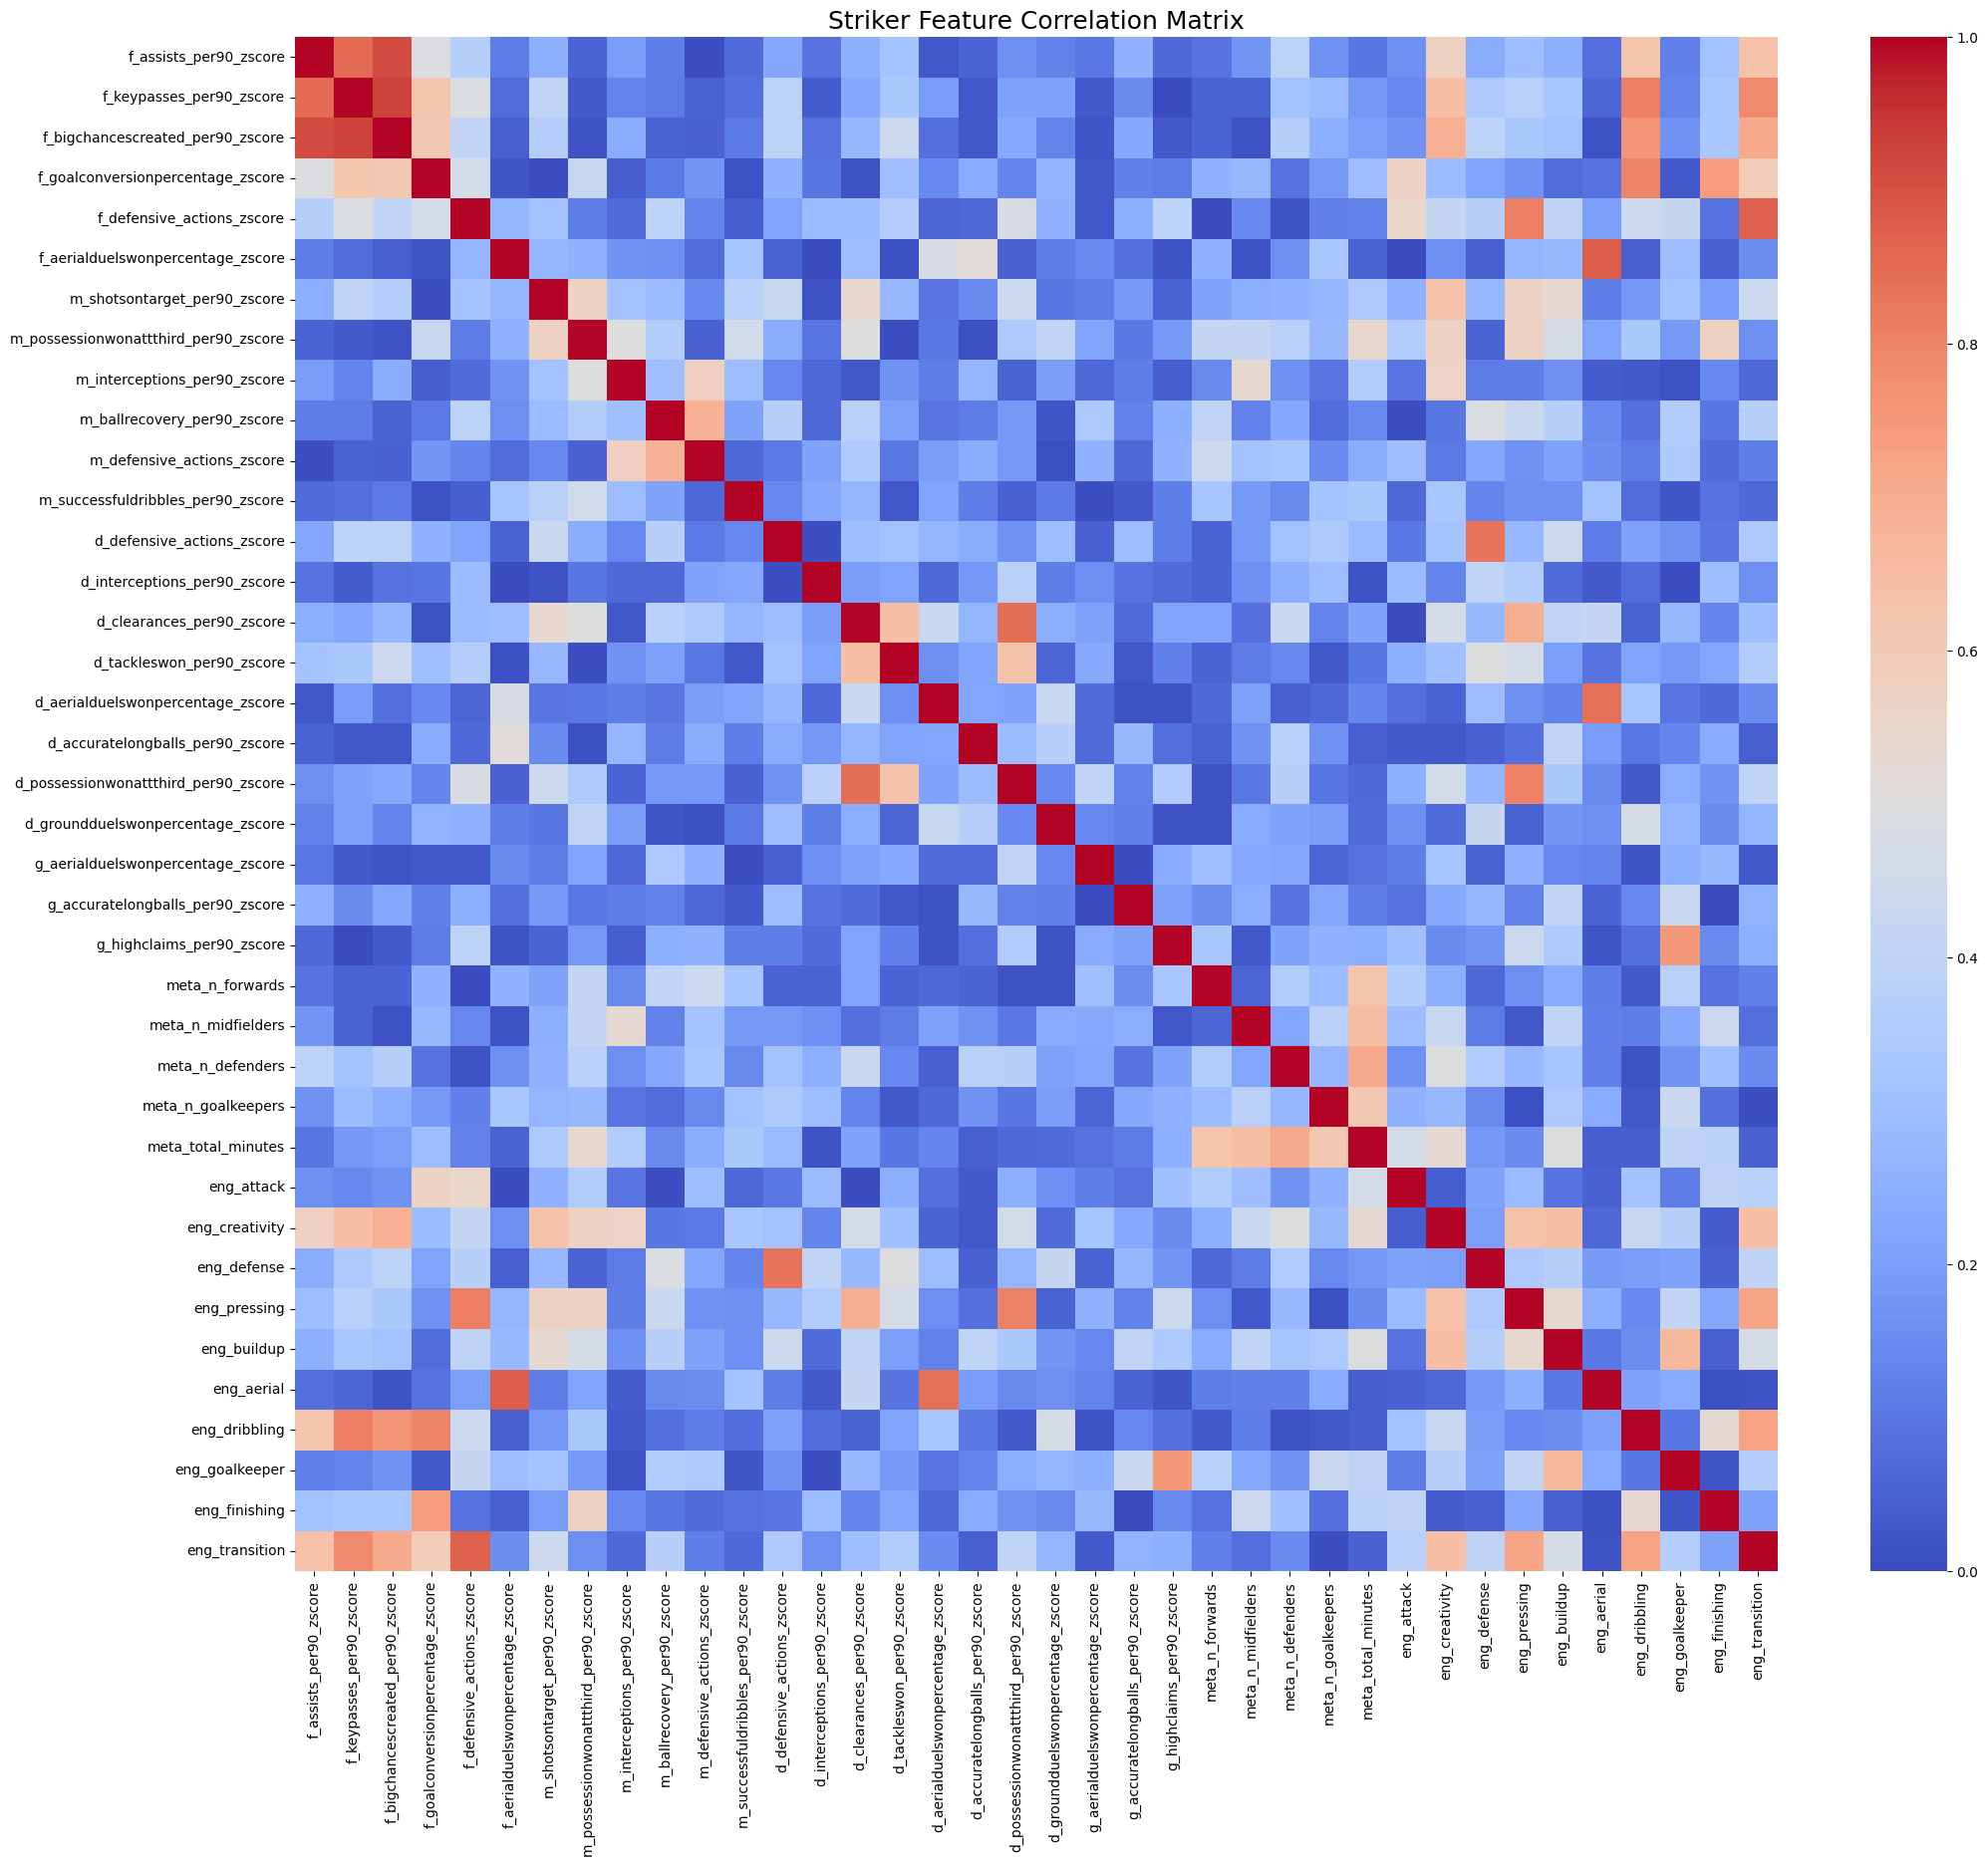

In [134]:
corr_matrix = nations_stats.drop(columns=['team_name' ]).corr().abs()

plt.figure(figsize=(24, 20))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, vmin=0, vmax=1)
plt.title("Striker Feature Correlation Matrix", fontsize=18)
plt.show()

In [135]:
corr_pairs = corr_matrix.unstack()
high_corr = corr_pairs[(corr_pairs > 0.80) & (corr_pairs < 1.0)].drop_duplicates().sort_values(ascending=False)

high_corr_df = pd.DataFrame(high_corr).reset_index()
high_corr_df.columns = ['Feature_1', 'Feature_2', 'Correlation']

with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(high_corr_df)

,Feature_1,Feature_2,Correlation
0,f_keypasses_per90_zscore,f_bigchancescreated_per90_zscore,0.929263
1,f_assists_per90_zscore,f_bigchancescreated_per90_zscore,0.911944
2,f_aerialduelswonpercentage_zscore,eng_aerial,0.876094
3,f_defensive_actions_zscore,eng_transition,0.873189
4,f_assists_per90_zscore,f_keypasses_per90_zscore,0.853409
5,d_clearances_per90_zscore,d_possessionwonattthird_per90_zscore,0.844979
6,d_aerialduelswonpercentage_zscore,eng_aerial,0.842754
7,d_defensive_actions_zscore,eng_defense,0.833473
8,f_defensive_actions_zscore,eng_pressing,0.811164
9,f_keypasses_per90_zscore,eng_dribbling,0.810833


In [133]:
drops = [
    'f_expectedgoals_per90_zscore',
    'f_goals_per_xg_zscore',
    'f_successfuldribbles_per90_zscore',
    'f_goals_minus_xg_per90_zscore',
    'f_shotsontarget_per90_zscore',
    'f_goals_per90_zscore',
    'd_accuratepasses_per90_zscore',
    'm_touches_per90_zscore',
    'd_touches_per90_zscore',
    'm_bigchancescreated_per90_zscore',
    'm_keypasses_per90_zscore',
    'g_saves_per90_zscore',
    'm_expectedassists_per90_zscore',
    'm_assists_per90_zscore',
    'm_expectedgoals_per90_zscore',
    'm_goals_per90_zscore',
    'f_expectedassists_per90_zscore'
]

nations_stats=nations_stats.drop(columns=drops)

In [136]:
nation_to_id = {
    nation: idx
    for idx, nation in enumerate(sorted(df_nation["nation"].unique()), start=1)
}

In [137]:
nations_stats["team_id"] = nations_stats["team_name"].map(nation_to_id)

In [141]:
nations_stats.head(15)

,team_name,f_assists_per90_zscore,f_keypasses_per90_zscore,f_bigchancescreated_per90_zscore,f_goalconversionpercentage_zscore,f_defensive_actions_zscore,f_aerialduelswonpercentage_zscore,m_shotsontarget_per90_zscore,m_possessionwonattthird_per90_zscore,m_interceptions_per90_zscore,...,eng_creativity,eng_defense,eng_pressing,eng_buildup,eng_aerial,eng_dribbling,eng_goalkeeper,eng_finishing,eng_transition,team_id
0,Ivory Coast,1.019309,0.353019,0.604855,0.028707,0.085867,0.224192,0.251498,0.251867,-0.353285,...,0.168890,0.189397,0.079912,0.202386,0.243889,0.268220,0.346728,-0.104520,0.234307,12
1,Canada,0.469415,-0.216145,0.121439,0.776701,-0.246840,-0.379006,0.056406,0.414907,-0.057800,...,-0.084284,-0.102857,-0.107147,0.314325,-0.296418,-0.355445,0.152693,-0.042205,-0.106917,6
2,Portugal,0.621969,0.531825,0.889411,-0.022233,-0.175637,0.153468,0.446372,0.522600,-0.480464,...,1.232332,0.144117,0.332696,1.061143,0.130920,0.244438,-0.449299,-0.145824,0.235500,16
3,Germany,0.606882,0.520268,0.585959,0.424194,0.114417,0.094361,0.408594,0.576243,-0.231386,...,0.774536,0.171645,0.231137,1.324978,0.228314,-0.027143,-0.394492,0.267864,0.185014,11
4,Belgium,1.028419,0.915221,1.149469,-0.186441,0.823586,-0.649039,0.119320,0.210988,-0.006986,...,0.790285,-0.019707,0.458708,0.526956,-0.370820,0.692011,-0.200189,0.191145,0.482460,4
5,Switzerland,-0.241801,-0.381055,-0.202123,0.544676,0.135149,0.622295,-0.438319,-0.275405,0.183013,...,-0.199547,0.080748,-0.225302,0.366882,0.230834,0.039814,-0.557690,0.279033,-0.006774,21
6,Spain,0.167343,0.295404,0.487596,0.198916,0.898548,-0.089895,0.680013,0.554533,-0.187163,...,0.938578,0.189099,0.605335,1.023769,-0.019204,0.439067,-0.448612,0.181795,0.529444,19
7,United States,0.394117,0.231767,0.431405,0.636159,-0.104798,-0.169384,0.190089,0.193233,0.094926,...,0.327534,0.112702,-0.029407,0.020822,-0.118990,0.052625,0.551817,0.186050,0.036011,23
8,Senegal,-0.232233,-0.012405,-0.011956,0.428032,-0.012808,0.031724,0.235947,0.027429,0.263064,...,-0.143107,0.379476,-0.135341,0.335629,0.345888,0.160378,-0.131260,-0.003590,0.064091,18
9,Netherlands,-0.050124,-0.007291,0.091055,0.791326,-0.702189,0.544084,0.513270,0.183296,-0.158543,...,0.153064,0.104815,-0.173304,0.521820,0.462443,-0.190204,0.229099,0.311190,-0.387918,14


In [142]:
nations_stats.to_csv('../../../data/processed/Teams/World_Cup_Nations_26.csv',index=False)